In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [87]:
df=pd.read_csv(r"C:\Users\NandhaKishore\Desktop\DEEP LEARNING\DAY 8\DATA SET\student_performance_interactions.csv")
df.head()

,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet


In [88]:
X = df[[
    'previous_score',
    'math_prev_score',
    'science_prev_score',
    'language_prev_score',
    'daily_study_hours',
    'attendance_percentage',
    'homework_completion_rate',
    'sleep_hours',
    'screen_time_hours',
    'physical_activity_minutes',
    'motivation_score',
    'exam_anxiety_score'
]]

y = df['pass_fail']

print("\nInput Shape :", X.shape)
print("Output Shape :", y.shape)


Input Shape : (1000, 12)
Output Shape : (1000,)


In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [90]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [98]:
# WITHOUT EARLY STOPPING

model1 = Sequential()

model1.add(Dense(64, activation='relu',
                 input_shape=(X_train.shape[1],)))

model1.add(Dense(32, activation='relu'))
model1.add(Dense(16, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_without_es = model1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8578 - loss: 0.5394 - val_accuracy: 0.9250 - val_loss: 0.3925
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9328 - loss: 0.3004 - val_accuracy: 0.9250 - val_loss: 0.2590
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9328 - loss: 0.2185 - val_accuracy: 0.9250 - val_loss: 0.2151
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9328 - loss: 0.1859 - val_accuracy: 0.9250 - val_loss: 0.1900
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1678 - val_accuracy: 0.9312 - val_loss: 0.1749
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9328 - loss: 0.1563 - val_accuracy: 0.9312 - val_loss: 0.1664
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1480 - val_accuracy: 0.9375 - val_loss: 0.1623
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9375 - loss: 0.1402 - val_accuracy: 0.9375 - val_los

In [103]:
# WITH EARLY STOPPING

model2 = Sequential()

model2.add(Dense(64, activation='relu',
                 input_shape=(X_train.shape[1],)))

model2.add(Dense(32, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_with_es = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6031 - loss: 0.6649 - val_accuracy: 0.9250 - val_loss: 0.4625
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9328 - loss: 0.3380 - val_accuracy: 0.9250 - val_loss: 0.2771
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9328 - loss: 0.2254 - val_accuracy: 0.9250 - val_loss: 0.2138
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9328 - loss: 0.1818 - val_accuracy: 0.9250 - val_loss: 0.1807
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9328 - loss: 0.1617 - val_accuracy: 0.9250 - val_loss: 0.1615
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9328 - loss: 0.1502 - val_accuracy: 0.9250 - val_loss: 0.1519
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9344 - loss: 0.1427 - val_accuracy: 0.9375 - val_loss: 0.1471
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9359 - loss: 0.1377 - val_accuracy: 0.9375 - val_los

In [101]:
loss1, acc1 = model1.evaluate(X_test, y_test)

loss2, acc2 = model2.evaluate(X_test, y_test)

print("\n===================================")
print("WITHOUT EARLY STOPPING")
print("===================================")

print("Test Accuracy :", acc1)
print("Test Loss :", loss1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9650 - loss: 0.1027  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9450 - loss: 0.1150  

WITHOUT EARLY STOPPING
Test Accuracy : 0.9649999737739563
Test Loss : 0.10269773751497269


In [102]:
print("\n===================================")
print("WITH EARLY STOPPING")
print("===================================")

print("Test Accuracy :", acc2)
print("Test Loss :", loss2)




WITH EARLY STOPPING
Test Accuracy : 0.9449999928474426
Test Loss : 0.114963598549366


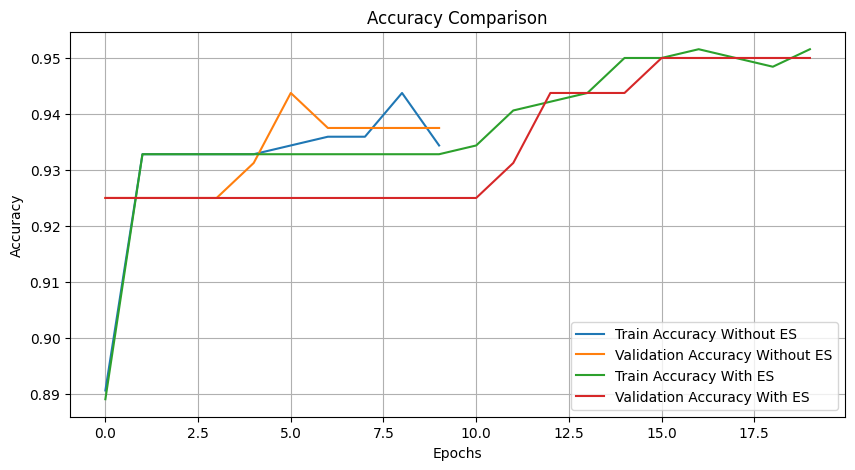

In [73]:
# =========================================================
# ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(10,5))

# Without ES
plt.plot(
    history_without_es.history['accuracy'],
    label='Train Accuracy Without ES'
)

plt.plot(
    history_without_es.history['val_accuracy'],
    label='Validation Accuracy Without ES'
)

# With ES
plt.plot(
    history_with_es.history['accuracy'],
    label='Train Accuracy With ES'
)

plt.plot(
    history_with_es.history['val_accuracy'],
    label='Validation Accuracy With ES'
)

plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


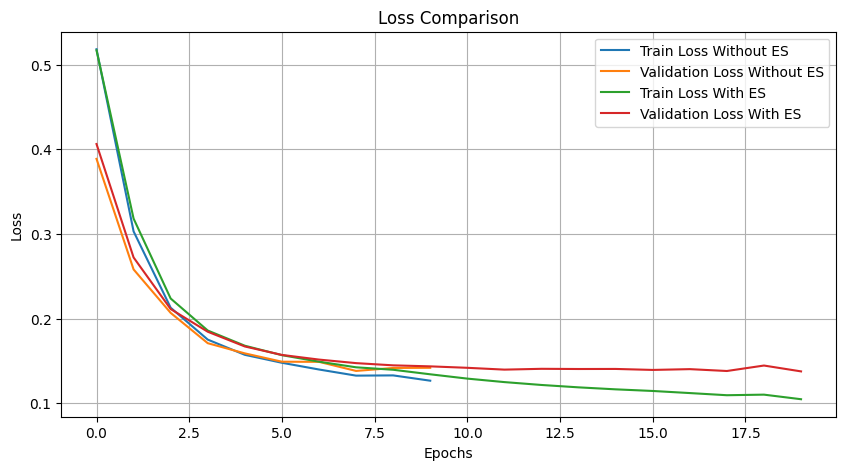

In [74]:
# =========================================================
# LOSS GRAPH
# =========================================================

plt.figure(figsize=(10,5))

# Without ES
plt.plot(
    history_without_es.history['loss'],
    label='Train Loss Without ES'
)

plt.plot(
    history_without_es.history['val_loss'],
    label='Validation Loss Without ES'
)

# With ES
plt.plot(
    history_with_es.history['loss'],
    label='Train Loss With ES'
)

plt.plot(
    history_with_es.history['val_loss'],
    label='Validation Loss With ES'
)

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()
